# Mini Project Notebook: Employee Attrition Prediction
## PRASHANTH KANNADAGULI
### SENIOR DATA SCIENCE TRAINER

## Problem Statement

To predict employee attrition using CatBoost and XgBoost

## Learning Objectives

At the end of the experiment, you will be able to

* explore the employee attrition dataset
* apply CatBoost and XgBoost on the dataset
* tune the model hyperparameters to improve accuracy
* evaluate the model using suitable metrics


## Introduction

Employee attrition is the gradual reduction in employee numbers. Employee attrition happens when the size of your workforce diminishes over time. This means that employees are leaving faster than they are hired. Employee attrition happens when employees retire, resign, or simply aren't replaced.
Although employee attrition can be company-wide, it may also be confined to specific parts of a business.

Employee attrition can happen for several reasons. These include unhappiness about employee benefits or the pay structure, a lack of employee development opportunities, and even poor conditions in the workplace.

To know more about the factors that lead to employee attrition, refer [here](https://www.betterup.com/blog/employee-attrition#:~:text=Employee%20attrition%20is%20the%20gradual,or%20simply%20aren't%20replaced).


**Gradient Boosted Decision Trees**

* Gradient boosted decision trees (GBDTs) are one of the most important machine learning models.

* GBDTs originate from AdaBoost, an algorithm that ensembles weak learners and uses the majority vote, weighted by their individual accuracy, to solve binary classification problems. The weak learners in this case are decision trees with a single split, called decision stumps.

* Some of the widely used gradient boosted decision trees are XgBoost, CatBoost and LightGBM.

## Dataset

The dataset used for this mini-project is [HR Employee Attrition dataset](https://data.world/aaizemberg/hr-employee-attrition). This dataset is synthetically created by IBM data scientists. There are 35 features and 1470 records.

There are numerical features such as:

* Age
* DistanceFromHome
* EmployeeNumber
* PerformanceRating

There are several categorical features such as:
* JobRole
* EducationField
* Department
* BusinessTravel

Dependent or target feature is 'attrition' which has values as Yes/No.

### Install CatBoost

In [1]:
!pip -qq install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.0 MB/s eta 0:00:00


### Import Required Packages

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier, metrics
import warnings
warnings.filterwarnings("ignore")
plt.style.use('fivethirtyeight')
pd.set_option('display.max_columns', 100)
%matplotlib inline

## Load the Dataset

**Exercise 1: Read the dataset**

**Hint:** pd.read_csv()

In [3]:
df = pd.read_excel("/content/sample_data/hr_employee_attrition_train.xlsx")

In [4]:

df.shape

(1170, 35)

There can be more than one file to read as this is introduced as a competition, dataset has one file for training the model. Their can be other files as one containing the test features and the other can be the true labels.

## Data Exploration

- Check for missing values
- Check for consistent data type across a feature
- Check for outliers or inconsistencies in data columns
- Check for correlated features
- Do we have a target label imbalance
- How our independent variables are distributed relative to our target label
- Are there features that have strong linear or monotonic relationships? Making correlation heatmaps makes it easy to identify possible collinearity

**Exercise 2: Create a `List` of numerical and categorical columns. Display a statistical description of the dataset. Remove missing values (if any)**

**Hint:** Use `for` to iterate through each column.

In [5]:
print("\n" + "="*90)
print("EXERCISE 2: DATA EXPLORATION")
print("="*90)

numerical_cols = []
categorical_cols = []

# Separate numerical and categorical columns
for col in df.columns:
    if df[col].dtype in ['int64', 'float64', 'int32', 'float32']:
        numerical_cols.append(col)
    else:
        categorical_cols.append(col)

print(f"\n✓ Identified {len(numerical_cols)} Numerical Columns:")
print(f"  {numerical_cols}")

print(f"\n✓ Identified {len(categorical_cols)} Categorical Columns:")
print(f"  {categorical_cols}")

# Statistical description
print("\n" + "-"*90)
print("STATISTICAL DESCRIPTION - NUMERICAL FEATURES")
print("-"*90)
print(df[numerical_cols].describe().round(3))

print("\n" + "-"*90)
print("CATEGORICAL FEATURES - UNIQUE VALUES")
print("-"*90)
for col in categorical_cols:
    print(f"\n{col}: {df[col].nunique()} unique values")
    print(f"  {df[col].value_counts().to_dict()}")

# Check for missing values
print("\n" + "-"*90)
print("MISSING VALUES CHECK")
print("-"*90)
missing_values = df.isnull().sum()
if missing_values.sum() == 0:
    print("✓ No missing values found!")
else:
    print("Missing values:")
    print(missing_values[missing_values > 0])
    df = df.dropna()
    print(f"✓ Missing values removed. New shape: {df.shape}")


EXERCISE 2: DATA EXPLORATION

✓ Identified 26 Numerical Columns:
  ['age', 'dailyrate', 'distancefromhome', 'education', 'employeecount', 'employeenumber', 'environmentsatisfaction', 'hourlyrate', 'jobinvolvement', 'joblevel', 'jobsatisfaction', 'monthlyincome', 'monthlyrate', 'numcompaniesworked', 'percentsalaryhike', 'performancerating', 'relationshipsatisfaction', 'standardhours', 'stockoptionlevel', 'totalworkingyears', 'trainingtimeslastyear', 'worklifebalance', 'yearsatcompany', 'yearsincurrentrole', 'yearssincelastpromotion', 'yearswithcurrmanager']

✓ Identified 9 Categorical Columns:
  ['businesstravel', 'department', 'educationfield', 'gender', 'jobrole', 'maritalstatus', 'over18', 'overtime', 'attrition']

------------------------------------------------------------------------------------------
STATISTICAL DESCRIPTION - NUMERICAL FEATURES
------------------------------------------------------------------------------------------
            age  dailyrate  distancefromhome 

First, we want to get a sense of our data:
- What features have the most divergent distributions based on target class
- Do we have a target label imbalance
- How our independent variables are distributed relative to our target label
- Are there features that have strong linear or monotonic relationships, making correlation heatmaps makes it easy to identify possible colinearity

### Check for outliers

**Exercise 3: Create a box plot to check for outliers**


EXERCISE 3: OUTLIER DETECTION

Number of numerical columns: 26
Creating subplots with flexible sizing...
Subplot grid: 7 x 4


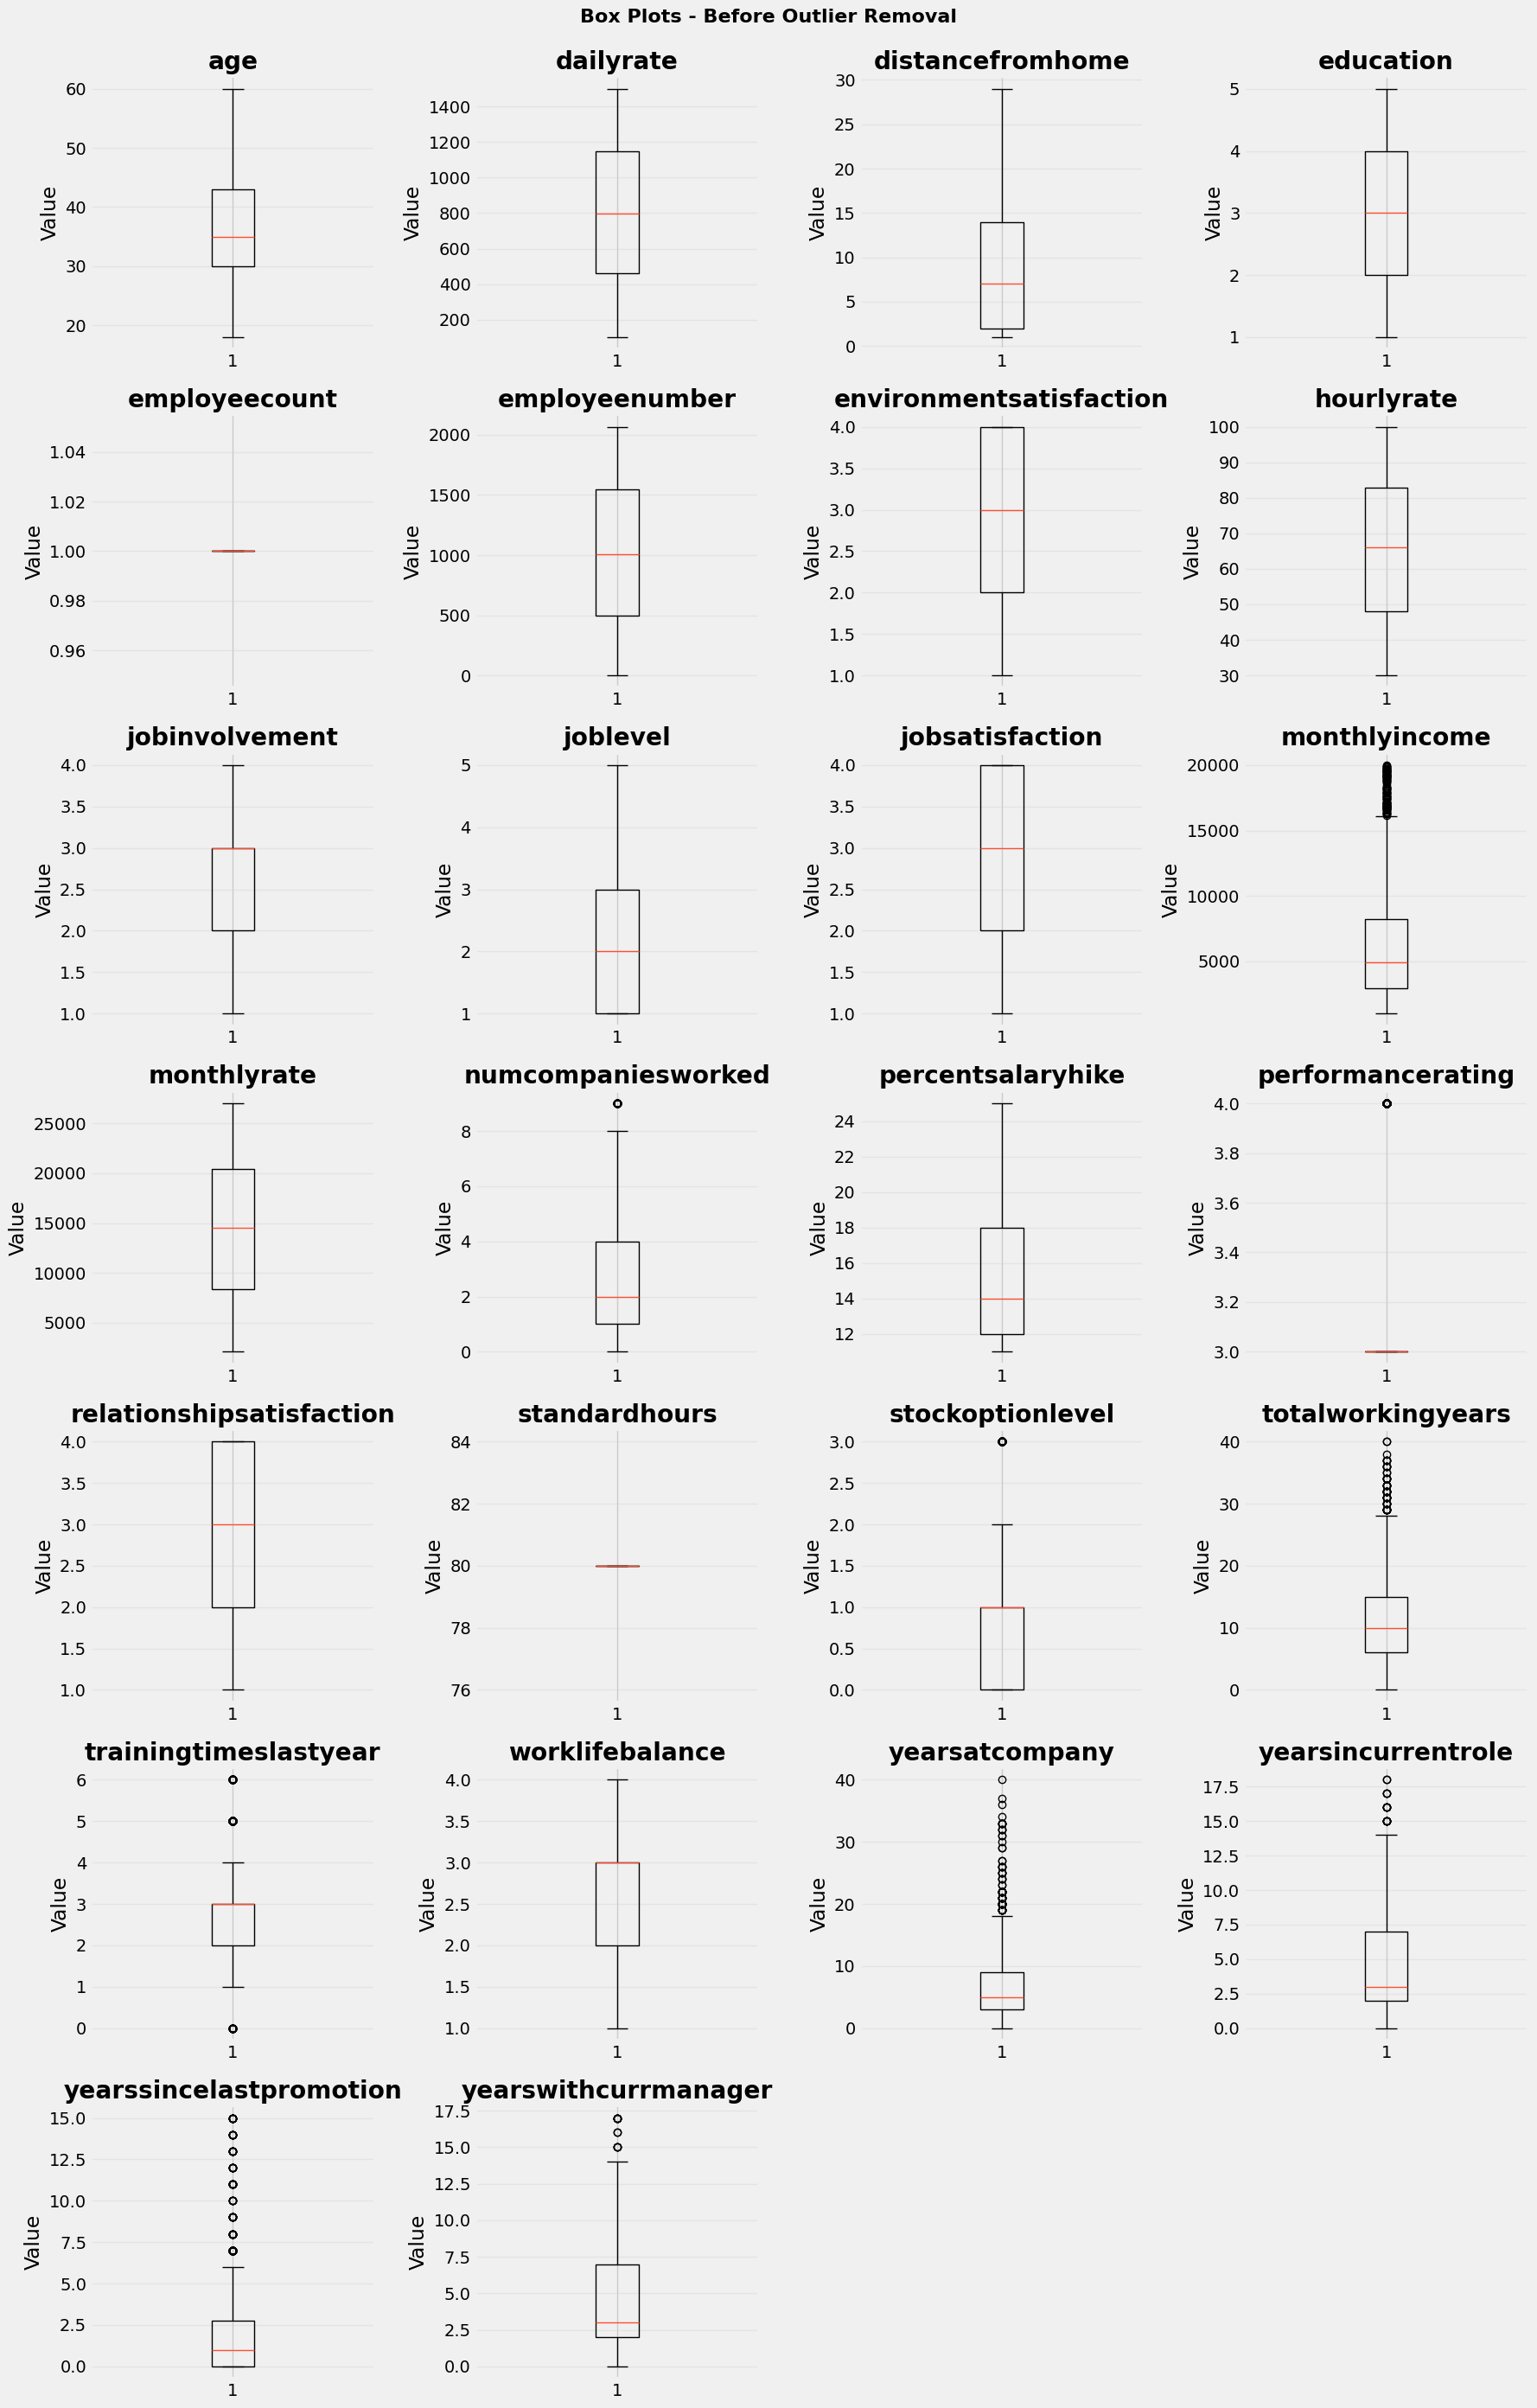

✓ Box plot saved as '01_boxplot_before_outlier_removal.png'

Original dataset shape: (1170, 35)


In [6]:
print("\n" + "="*90)
print("EXERCISE 3: OUTLIER DETECTION")
print("="*90)

print(f"\nNumber of numerical columns: {len(numerical_cols)}")
print(f"Creating subplots with flexible sizing...")

# Calculate optimal subplot dimensions
num_cols = len(numerical_cols)
subplot_rows = (num_cols + 3) // 4  # Ceiling division to fit all plots
subplot_cols = 4

print(f"Subplot grid: {subplot_rows} x {subplot_cols}")

plt.figure(figsize=(18, subplot_rows * 4))
plt.suptitle('Box Plots - Before Outlier Removal', fontsize=16, fontweight='bold', y=0.995)

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(subplot_rows, subplot_cols, i)
    plt.boxplot(df[col], vert=True)
    plt.title(col, fontweight='bold')
    plt.ylabel('Value')
    plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('01_boxplot_before_outlier_removal.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Box plot saved as '01_boxplot_before_outlier_removal.png'")
print(f"\nOriginal dataset shape: {df.shape}")

### Handling outliers

**Exercise 4: Use lower bound as 25% and upper bound as 75% to handle the outliers**

In [7]:
print("\n" + "="*90)
print("EXERCISE 4: OUTLIER REMOVAL (IQR METHOD)")
print("="*90)

df_cleaned = df.copy()
removed_rows = 0

print("\nRemoving outliers using IQR method (Q1: 25%, Q3: 75%)...")
print("-"*90)

for col in numerical_cols:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_count = len(df_cleaned[(df_cleaned[col] < lower_bound) | (df_cleaned[col] > upper_bound)])

    if outliers_count > 0:
        print(f"{col:25s} | Q1: {Q1:10.2f} | Q3: {Q3:10.2f} | IQR: {IQR:10.2f} | Outliers: {outliers_count}")

    df_cleaned = df_cleaned[(df_cleaned[col] >= lower_bound) & (df_cleaned[col] <= upper_bound)]

removed_rows = df.shape[0] - df_cleaned.shape[0]
print("-"*90)
print(f"✓ Total rows removed: {removed_rows}")
print(f"✓ New dataset shape: {df_cleaned.shape}")


EXERCISE 4: OUTLIER REMOVAL (IQR METHOD)

Removing outliers using IQR method (Q1: 25%, Q3: 75%)...
------------------------------------------------------------------------------------------
monthlyincome             | Q1:    2914.75 | Q3:    8215.25 | IQR:    5300.50 | Outliers: 94
numcompaniesworked        | Q1:       1.00 | Q3:       4.00 | IQR:       3.00 | Outliers: 42
performancerating         | Q1:       3.00 | Q3:       3.00 | IQR:       0.00 | Outliers: 163
stockoptionlevel          | Q1:       0.00 | Q3:       1.00 | IQR:       1.00 | Outliers: 54
totalworkingyears         | Q1:       6.00 | Q3:      13.00 | IQR:       7.00 | Outliers: 38
trainingtimeslastyear     | Q1:       2.00 | Q3:       3.00 | IQR:       1.00 | Outliers: 142
yearsatcompany            | Q1:       2.00 | Q3:       8.00 | IQR:       6.00 | Outliers: 21
yearsincurrentrole        | Q1:       2.00 | Q3:       7.00 | IQR:       5.00 | Outliers: 1
yearssincelastpromotion   | Q1:       0.00 | Q3:       2.00 | IQ


Verifying outlier removal...


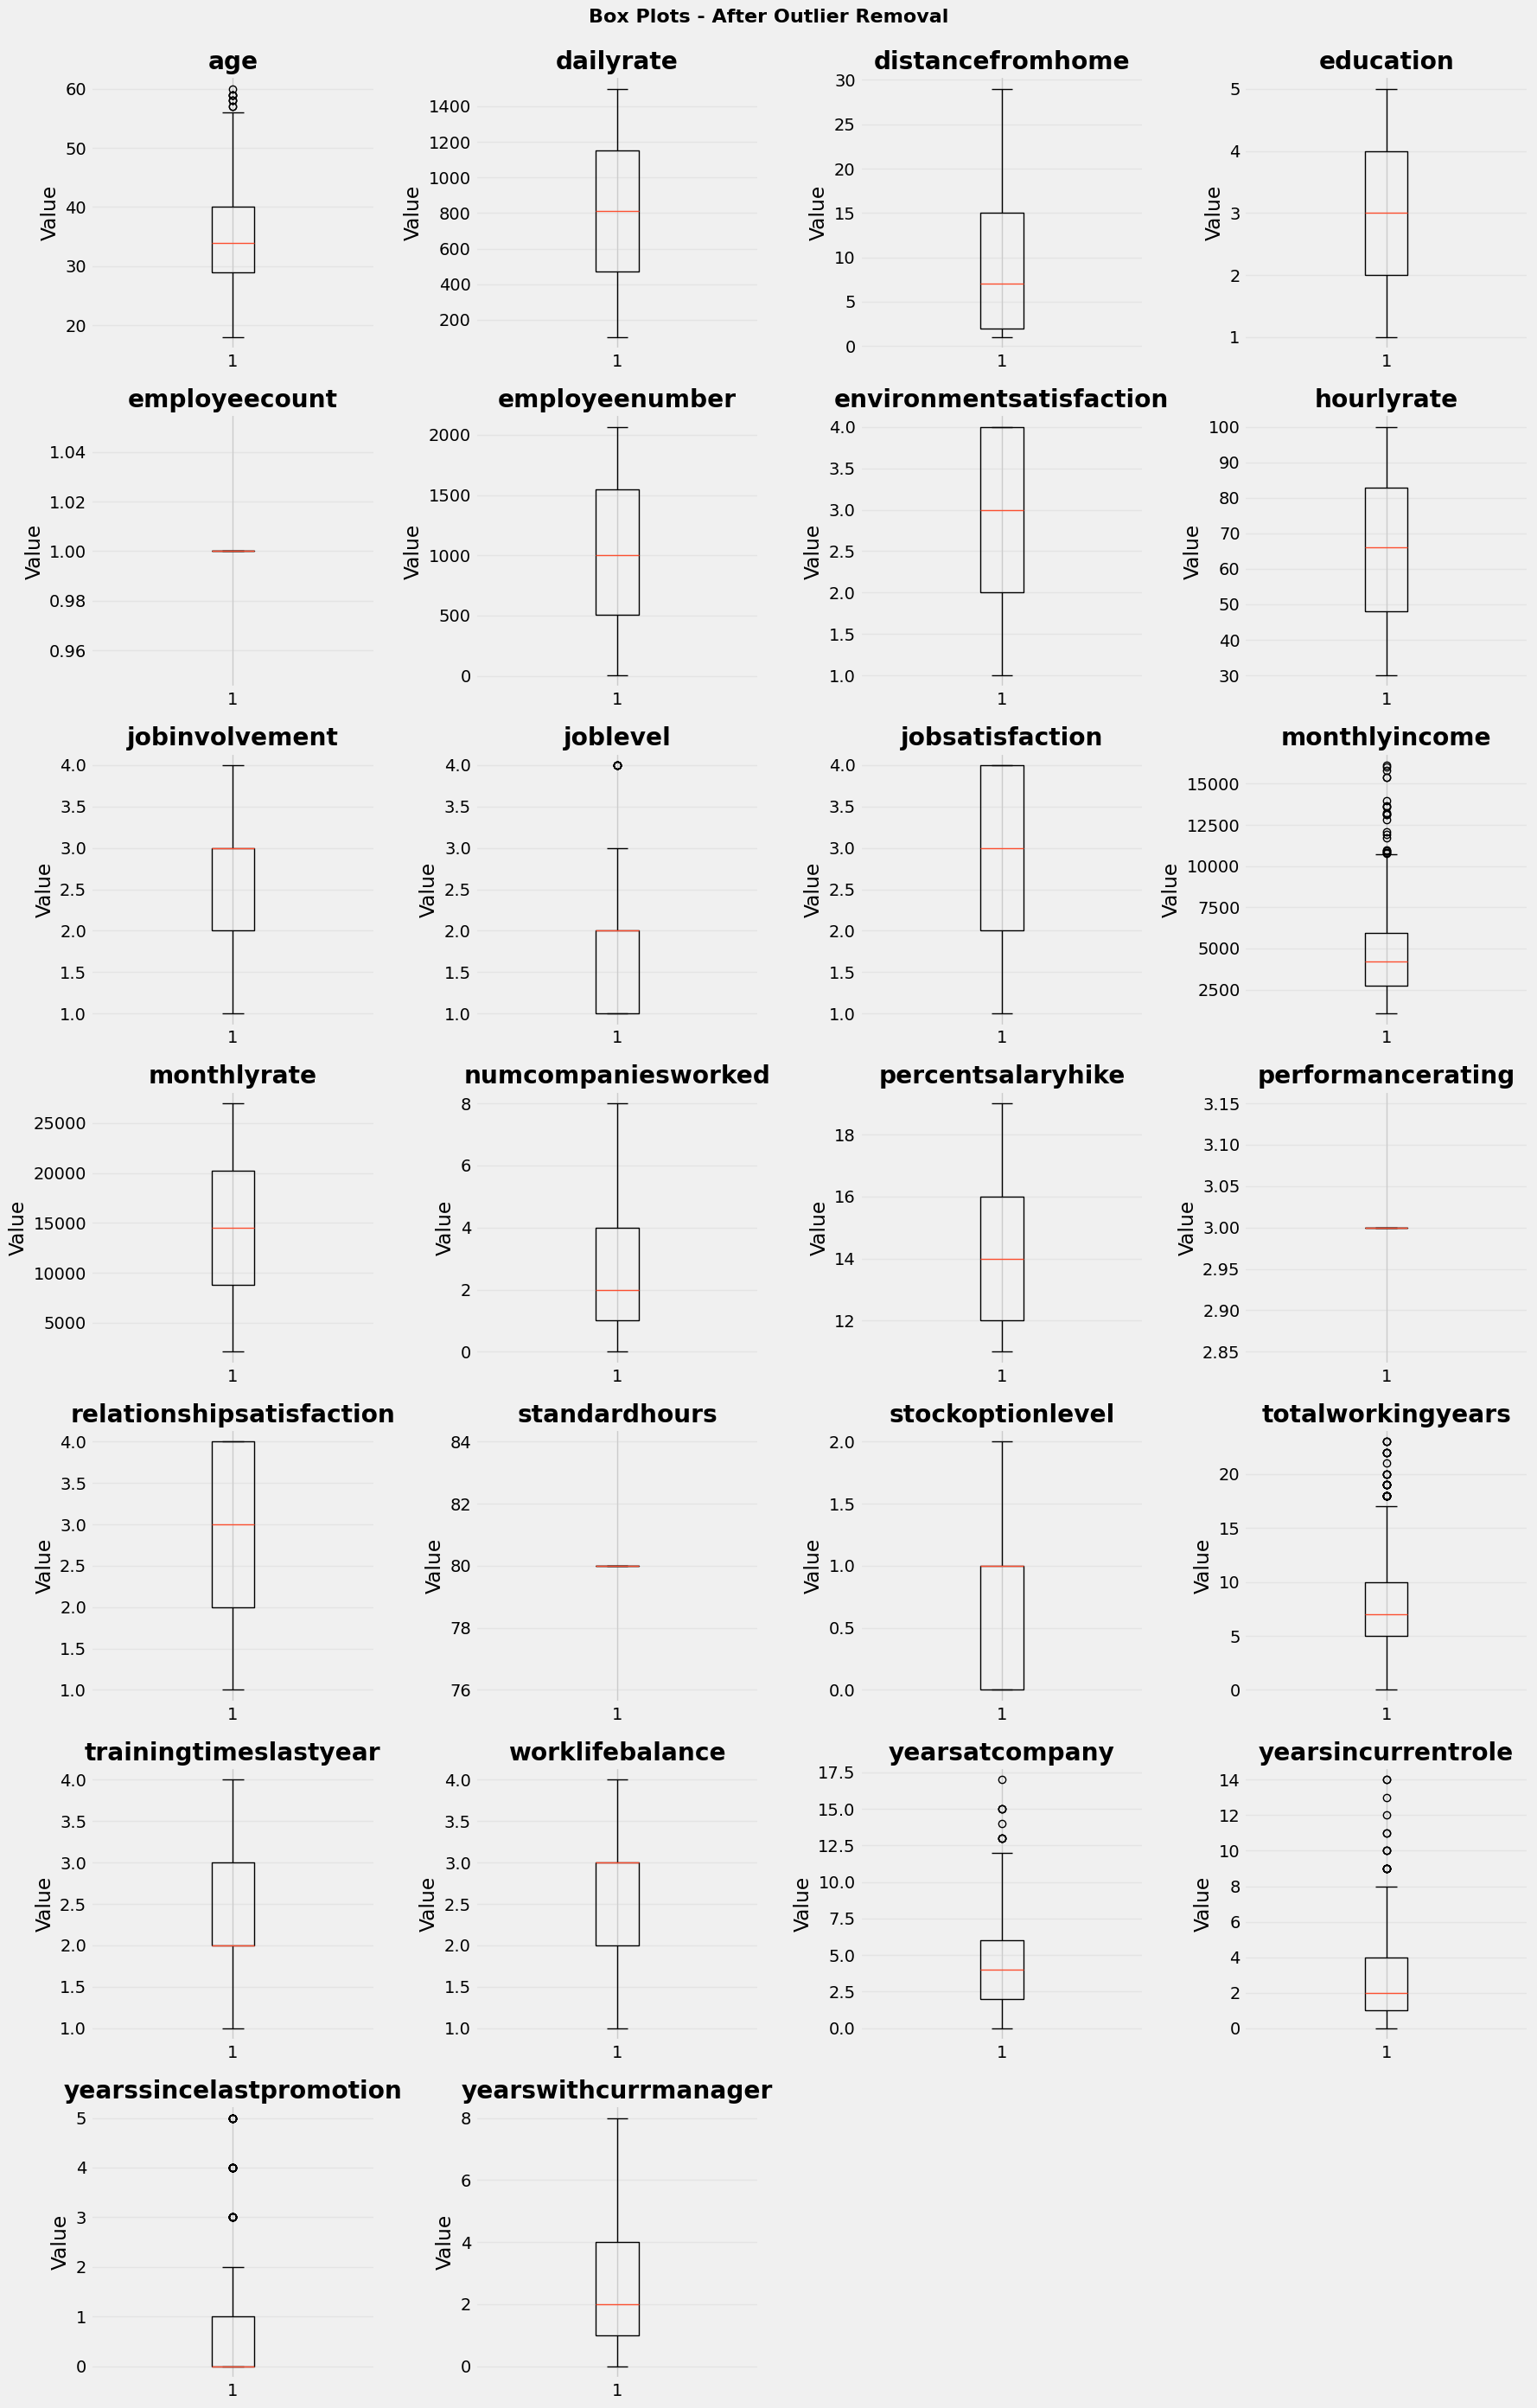

✓ Box plot saved as '02_boxplot_after_outlier_removal.png'


In [8]:
print("\nVerifying outlier removal...")

plt.figure(figsize=(18, subplot_rows * 4))
plt.suptitle('Box Plots - After Outlier Removal', fontsize=16, fontweight='bold', y=0.995)

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(subplot_rows, subplot_cols, i)
    plt.boxplot(df_cleaned[col], vert=True)
    plt.title(col, fontweight='bold')
    plt.ylabel('Value')
    plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('02_boxplot_after_outlier_removal.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Box plot saved as '02_boxplot_after_outlier_removal.png'")

### Target label imbalance

**Exercise 5: Check if there is an imbalance in target label**

**Hint:** Use value_counts()

In [9]:
print("\n" + "="*90)
print("EXERCISE 5: TARGET LABEL IMBALANCE CHECK")
print("="*90)

target_col = 'attrition'   # changed to lowercase

if target_col in df_cleaned.columns:
    print(f"\n{target_col} Distribution:")
    print("-"*90)

    attrition_counts = df_cleaned[target_col].value_counts()
    print(attrition_counts)

    print("\nPercentage Distribution:")
    print("-"*90)

    attrition_pct = df_cleaned[target_col].value_counts(normalize=True) * 100
    for label, pct in attrition_pct.items():
        print(f"{label:20s}: {pct:6.2f}%")

    imbalance_ratio = attrition_counts.max() / attrition_counts.min()
    print(f"\nImbalance Ratio: {imbalance_ratio:.2f}")


EXERCISE 5: TARGET LABEL IMBALANCE CHECK

attrition Distribution:
------------------------------------------------------------------------------------------
attrition
No     426
Yes     93
Name: count, dtype: int64

Percentage Distribution:
------------------------------------------------------------------------------------------
No                  :  82.08%
Yes                 :  17.92%

Imbalance Ratio: 4.58


(array([0, 1]), [Text(0, 0, 'No'), Text(1, 0, 'Yes')])

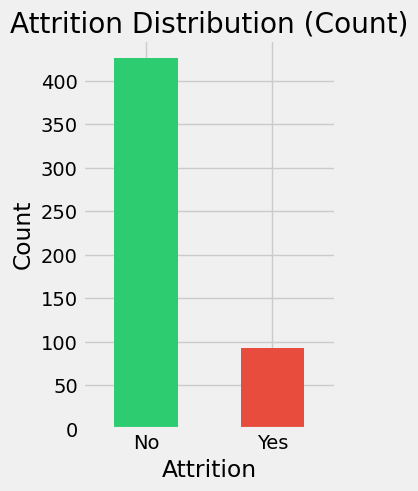

In [10]:


    # Bar Plot
    plt.subplot(1,2,1)
    colors = ['#2ecc71', '#e74c3c']
    attrition_counts.plot(kind='bar', color=colors)
    plt.title("Attrition Distribution (Count)")
    plt.xlabel("Attrition")
    plt.ylabel("Count")
    plt.xticks(rotation=0)



If there is any imbalance in the dataset then a few techniques can be utilised (optional):
1. SMOTE
2. Cross Validation
3. Regularizing the model's parameters

###Plot pairplot

**Exercise 6: Visualize the relationships between the predictor variables and the target variable using a pairplot**

**Hint:** Use sns.pairplot


EXERCISE 6: PAIRPLOT - RELATIONSHIPS VISUALIZATION
Features used: ['age', 'monthlyincome', 'yearsatcompany', 'distancefromhome', 'attrition']


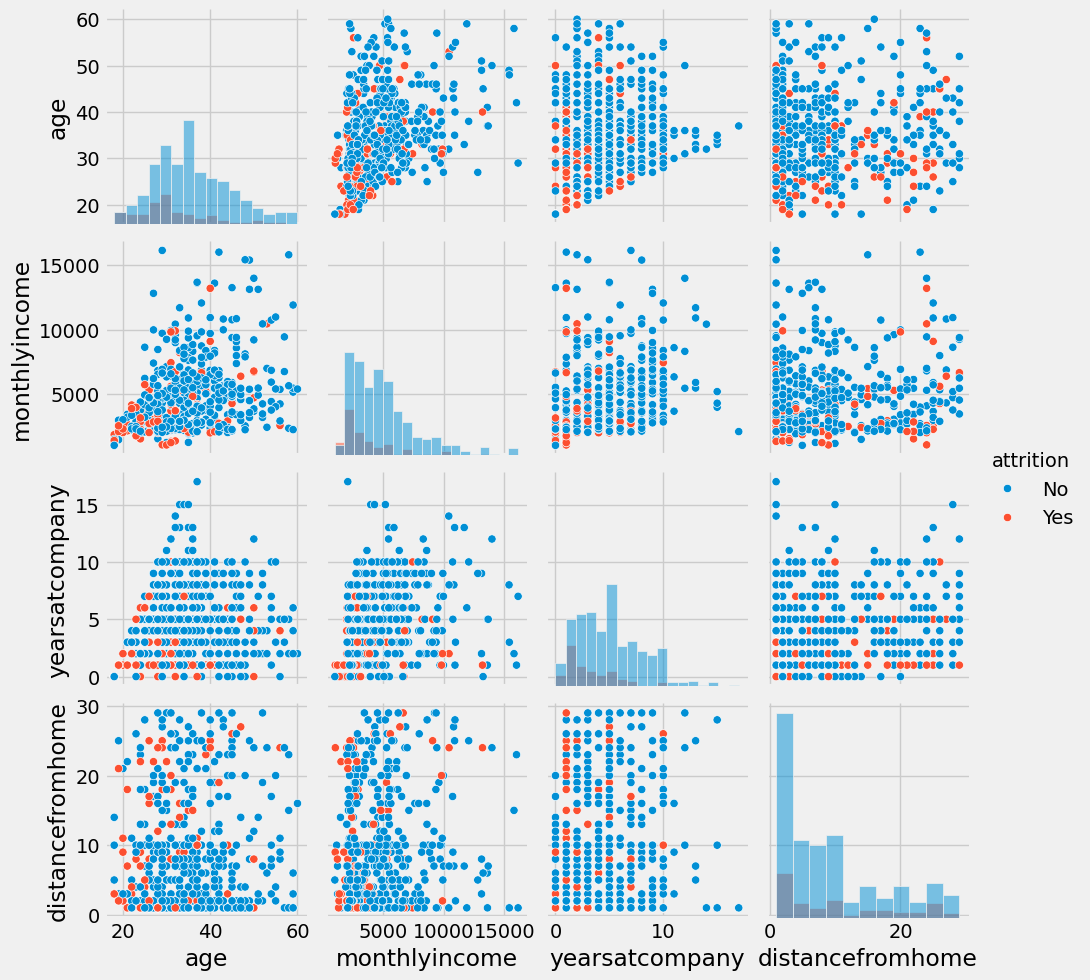

In [11]:
# Exercise 6: Visualize the relationships between predictor variables and target variable

import seaborn as sns
import matplotlib.pyplot as plt

print("\n" + "="*90)
print("EXERCISE 6: PAIRPLOT - RELATIONSHIPS VISUALIZATION")
print("="*90)

# Features to include in pairplot
pairplot_features = [
    'age',
    'monthlyincome',
    'yearsatcompany',
    'distancefromhome',
    'attrition'
]

# Keep only columns that exist
pairplot_features = [col for col in pairplot_features if col in df_cleaned.columns]

print("Features used:", pairplot_features)

# Create pairplot
sns.pairplot(
    data=df_cleaned[pairplot_features],
    hue='attrition',
    diag_kind='hist'
)

plt.show()

### Explore Correlation

- Plotting the Heatmap

**Exercise 7: Visualize the correlation among IBM employee attrition numerical features using a heatmap**


EXERCISE 7: CORRELATION HEATMAP

Calculating correlation matrix...


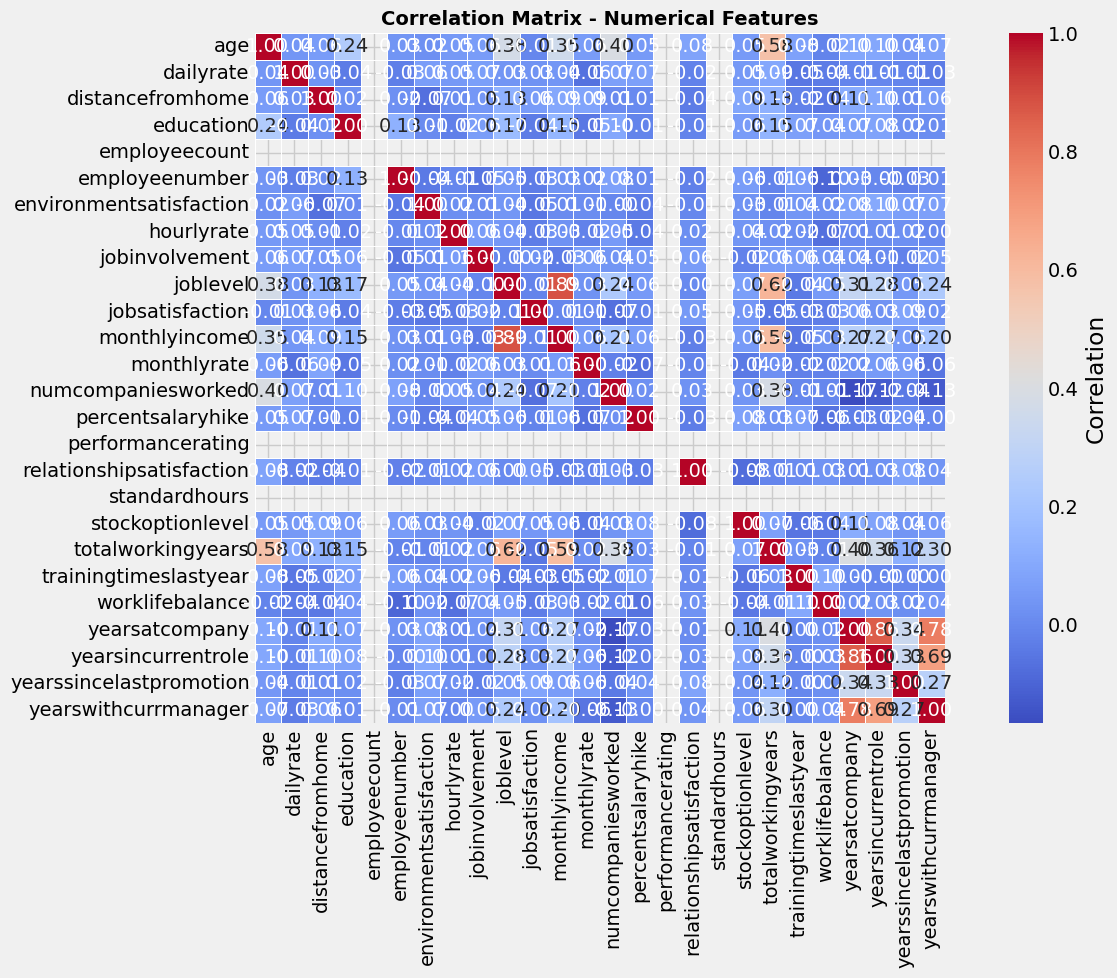

✓ Correlation heatmap saved as '05_correlation_heatmap.png'


In [12]:
print("\n" + "="*90)
print("EXERCISE 7: CORRELATION HEATMAP")
print("="*90)

print("\nCalculating correlation matrix...")

plt.figure(figsize=(14, 10))
correlation_matrix = df_cleaned[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f',
            cbar_kws={'label': 'Correlation'}, square=True, linewidths=0.5)
plt.title('Correlation Matrix - Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('05_correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Correlation heatmap saved as '05_correlation_heatmap.png'")

Comment on the observations made with the pairplot and heatmap

### Preparing the test feature space
* Remove outliers if any
* Handle the categorical feature if required
* Other processing steps can also be followed.

In [13]:
print("\nHighly Correlated Feature Pairs (|correlation| > 0.7):")
print("-"*90)
corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            corr_pairs.append((correlation_matrix.columns[i],
                             correlation_matrix.columns[j],
                             correlation_matrix.iloc[i, j]))

if corr_pairs:
    for col1, col2, corr in sorted(corr_pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f"{col1:25s} <-> {col2:25s} : {corr:7.4f}")
else:
    print("No highly correlated pairs found (threshold: 0.7)")


Highly Correlated Feature Pairs (|correlation| > 0.7):
------------------------------------------------------------------------------------------
joblevel                  <-> monthlyincome             :  0.8851
yearsatcompany            <-> yearsincurrentrole        :  0.8604
yearsatcompany            <-> yearswithcurrmanager      :  0.7826


Optional:
Use `Hyperopt`, a hyperparameter tuning technique to identify the best set of parameters.



In the notebook, data processing is done separately for different models.
Considering the fact that different models may require data in different format and in turn different processes may be followed to process the data.
If the processing steps followed for the models are same, data processing can also be done once.

## Apply CatBoost

Catboost was released in 2017 by Yandex, showing, by their benchmark to be faster in prediction, better in accuracy, and easier to use for categorical data across a series of GBDT tasks. Additional capabilities of catboost include plotting feature interactions and object (row) importance.

[Here](https://catboost.ai/en/docs/) is the official documentation of CatBoost

### Data Processing for CatBoost

**Exercise 8: Data processing for CatBoost**
* **Copy the dataframe that was created after removing the outliers**
* **Handle the categorical features if required**
* **Create target column and feature space**

**Hint:** Column containing the information on attrition will be the target column.

In [14]:
print("\n" + "="*90)
print("EXERCISE 8: DATA PROCESSING FOR CATBOOST")
print("="*90)

# Copy the dataframe
catboost_df = df_cleaned.copy()

print("Dataframe copied successfully.")
print("Shape:", catboost_df.shape)


EXERCISE 8: DATA PROCESSING FOR CATBOOST
Dataframe copied successfully.
Shape: (519, 35)


In [15]:
# Target Column
target_col = 'attrition'

y = catboost_df[target_col].map({'Yes': 1, 'No': 0})

print("Target shape:", y.shape)
print(y.value_counts())

Target shape: (519,)
attrition
0    426
1     93
Name: count, dtype: int64


In [16]:
# Feature Space
X = catboost_df.drop(columns=[target_col])

print("Feature Space Shape:", X.shape)
X.head()

Feature Space Shape: (519, 34)


,age,businesstravel,dailyrate,department,distancefromhome,education,educationfield,employeecount,employeenumber,environmentsatisfaction,gender,hourlyrate,jobinvolvement,joblevel,jobrole,jobsatisfaction,maritalstatus,monthlyincome,monthlyrate,numcompaniesworked,over18,overtime,percentsalaryhike,performancerating,relationshipsatisfaction,standardhours,stockoptionlevel,totalworkingyears,trainingtimeslastyear,worklifebalance,yearsatcompany,yearsincurrentrole,yearssincelastpromotion,yearswithcurrmanager
0,45,Travel_Rarely,556,Research & Development,25,2,Life Sciences,1,1888,2,Female,93,2,2,Manufacturing Director,4,Married,5906,23888,0,Y,No,13,3,4,80,2,10,2,2,9,8,3,8
1,34,Travel_Rarely,970,Research & Development,8,2,Medical,1,757,2,Female,96,3,2,Healthcare Representative,3,Single,6142,7360,3,Y,No,11,3,4,80,0,10,2,3,5,1,4,3
2,39,Travel_Rarely,360,Research & Development,23,3,Medical,1,1310,3,Male,93,3,1,Research Scientist,1,Single,3904,22154,0,Y,No,13,3,1,80,0,6,2,3,5,2,0,3
5,29,Travel_Rarely,408,Research & Development,25,5,Technical Degree,1,565,3,Female,71,2,1,Research Scientist,2,Married,2546,18300,5,Y,No,16,3,2,80,0,6,2,4,2,2,1,1
6,57,Travel_Rarely,593,Research & Development,1,4,Medical,1,482,4,Male,88,3,2,Healthcare Representative,3,Married,6755,2967,2,Y,No,11,3,3,80,0,15,2,3,3,2,1,2


### Model Definition

**Exercise 9: Define, train the model and display the results**

**Hint:**
* Use CatBoostClassifier() to define the model with relevant parameters.
* Use `fit` to fit the data to the model. Refer [here](https://catboost.ai/en/docs/concepts/speed-up-training) to see some ways to speedup CatBoost training.
* Evaluate the model using roc_auc_score, accuracy_score, f1_score, predict methods or other relevant techniques.

In [17]:
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Find categorical feature indices
cat_features = [i for i, col in enumerate(X.columns)
                if X[col].dtype == 'object']

# Create CatBoost model
cat_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=100
)

In [18]:
cat_model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test),
    verbose=False
)

CatBoostClassifier(depth=6, eval_metric='AUC', iterations=300, learning_rate=0.1, loss_function='Logloss', random_seed=42, verbose=100)

### Model performance

In [19]:
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, classification_report

y_pred = cat_model.predict(X_test)
y_prob = cat_model.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy : 0.7980769230769231
ROC-AUC  : 0.761609907120743
F1 Score : 0.16

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.95      0.89        85
           1       0.33      0.11      0.16        19

    accuracy                           0.80       104
   macro avg       0.58      0.53      0.52       104
weighted avg       0.74      0.80      0.75       104



## Apply XGBoost

XGBoost is a workhorse gradient boosted decision tree algorithm. Its been around since 2014 and has come to dominate the Kaggle and data science community. XGB introduced gradient boosting where new models are fit to the residuals of prior models and then added together, using a gradient descent algorithm to minimize the loss.

Read [here](https://xgboost.readthedocs.io/en/stable/parameter.html) on XGBoost parameters.

Refer [here](https://xgboost.readthedocs.io/en/stable/python/python_api.html#xgboost.XGBClassifier) for the official documentation of XGBoost classifier.

### Data Processing for XGBoost


**Exercise 10: Data Processing for XGBoost**
* **Copy the dataframe after the outliers were removed.**
* **Handle the categorical features if required**
* **Create target column and feature space**

In [20]:
# Copy dataframe
xgb_df = df_cleaned.copy()
xgb_df.head()

,age,businesstravel,dailyrate,department,distancefromhome,education,educationfield,employeecount,employeenumber,environmentsatisfaction,gender,hourlyrate,jobinvolvement,joblevel,jobrole,jobsatisfaction,maritalstatus,monthlyincome,monthlyrate,numcompaniesworked,over18,overtime,percentsalaryhike,performancerating,relationshipsatisfaction,standardhours,stockoptionlevel,totalworkingyears,trainingtimeslastyear,worklifebalance,yearsatcompany,yearsincurrentrole,yearssincelastpromotion,yearswithcurrmanager,attrition
0,45,Travel_Rarely,556,Research & Development,25,2,Life Sciences,1,1888,2,Female,93,2,2,Manufacturing Director,4,Married,5906,23888,0,Y,No,13,3,4,80,2,10,2,2,9,8,3,8,No
1,34,Travel_Rarely,970,Research & Development,8,2,Medical,1,757,2,Female,96,3,2,Healthcare Representative,3,Single,6142,7360,3,Y,No,11,3,4,80,0,10,2,3,5,1,4,3,No
2,39,Travel_Rarely,360,Research & Development,23,3,Medical,1,1310,3,Male,93,3,1,Research Scientist,1,Single,3904,22154,0,Y,No,13,3,1,80,0,6,2,3,5,2,0,3,Yes
5,29,Travel_Rarely,408,Research & Development,25,5,Technical Degree,1,565,3,Female,71,2,1,Research Scientist,2,Married,2546,18300,5,Y,No,16,3,2,80,0,6,2,4,2,2,1,1,Yes
6,57,Travel_Rarely,593,Research & Development,1,4,Medical,1,482,4,Male,88,3,2,Healthcare Representative,3,Married,6755,2967,2,Y,No,11,3,3,80,0,15,2,3,3,2,1,2,No


**Hint:** Use pd.get_dummies

In [21]:
# Handling categorical features
xgb_df = pd.get_dummies(xgb_df, drop_first=True)
xgb_df.head()

,age,dailyrate,distancefromhome,education,employeecount,employeenumber,environmentsatisfaction,hourlyrate,jobinvolvement,joblevel,jobsatisfaction,monthlyincome,monthlyrate,numcompaniesworked,percentsalaryhike,performancerating,relationshipsatisfaction,standardhours,stockoptionlevel,totalworkingyears,trainingtimeslastyear,worklifebalance,yearsatcompany,yearsincurrentrole,yearssincelastpromotion,yearswithcurrmanager,businesstravel_Travel_Frequently,businesstravel_Travel_Rarely,department_Research & Development,department_Sales,educationfield_Life Sciences,educationfield_Marketing,educationfield_Medical,educationfield_Other,educationfield_Technical Degree,gender_Male,jobrole_Human Resources,jobrole_Laboratory Technician,jobrole_Manager,jobrole_Manufacturing Director,jobrole_Research Director,jobrole_Research Scientist,jobrole_Sales Executive,jobrole_Sales Representative,maritalstatus_Married,maritalstatus_Single,overtime_Yes,attrition_Yes
0,45,556,25,2,1,1888,2,93,2,2,4,5906,23888,0,13,3,4,80,2,10,2,2,9,8,3,8,False,True,True,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False
1,34,970,8,2,1,757,2,96,3,2,3,6142,7360,3,11,3,4,80,0,10,2,3,5,1,4,3,False,True,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
2,39,360,23,3,1,1310,3,93,3,1,1,3904,22154,0,13,3,1,80,0,6,2,3,5,2,0,3,False,True,True,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,True
5,29,408,25,5,1,565,3,71,2,1,2,2546,18300,5,16,3,2,80,0,6,2,4,2,2,1,1,False,True,True,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,True,False,False,True
6,57,593,1,4,1,482,4,88,3,2,3,6755,2967,2,11,3,3,80,0,15,2,3,3,2,1,2,False,True,True,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False


In [22]:
# Concat the dummy variables to actual dataframe and remove initial categorical columns
print("Dummy variables created successfully.")
print("Shape:", xgb_df.shape)

Dummy variables created successfully.
Shape: (519, 48)


When creating the dummy variables, the name of attrition column was changed, rename to 'attrition' again.

**Hint:** Use .rename

In [23]:
# Rename target column
if 'attrition_Yes' in xgb_df.columns:
    xgb_df.rename(columns={'attrition_Yes': 'attrition'}, inplace=True)

print(xgb_df.columns)

Index(['age', 'dailyrate', 'distancefromhome', 'education', 'employeecount',
       'employeenumber', 'environmentsatisfaction', 'hourlyrate',
       'jobinvolvement', 'joblevel', 'jobsatisfaction', 'monthlyincome',
       'monthlyrate', 'numcompaniesworked', 'percentsalaryhike',
       'performancerating', 'relationshipsatisfaction', 'standardhours',
       'stockoptionlevel', 'totalworkingyears', 'trainingtimeslastyear',
       'worklifebalance', 'yearsatcompany', 'yearsincurrentrole',
       'yearssincelastpromotion', 'yearswithcurrmanager',
       'businesstravel_Travel_Frequently', 'businesstravel_Travel_Rarely',
       'department_Research & Development', 'department_Sales',
       'educationfield_Life Sciences', 'educationfield_Marketing',
       'educationfield_Medical', 'educationfield_Other',
       'educationfield_Technical Degree', 'gender_Male',
       'jobrole_Human Resources', 'jobrole_Laboratory Technician',
       'jobrole_Manager', 'jobrole_Manufacturing Director',
  

In [24]:
# Feature Space
X = xgb_df.drop('attrition', axis=1)
X.head()

,age,dailyrate,distancefromhome,education,employeecount,employeenumber,environmentsatisfaction,hourlyrate,jobinvolvement,joblevel,jobsatisfaction,monthlyincome,monthlyrate,numcompaniesworked,percentsalaryhike,performancerating,relationshipsatisfaction,standardhours,stockoptionlevel,totalworkingyears,trainingtimeslastyear,worklifebalance,yearsatcompany,yearsincurrentrole,yearssincelastpromotion,yearswithcurrmanager,businesstravel_Travel_Frequently,businesstravel_Travel_Rarely,department_Research & Development,department_Sales,educationfield_Life Sciences,educationfield_Marketing,educationfield_Medical,educationfield_Other,educationfield_Technical Degree,gender_Male,jobrole_Human Resources,jobrole_Laboratory Technician,jobrole_Manager,jobrole_Manufacturing Director,jobrole_Research Director,jobrole_Research Scientist,jobrole_Sales Executive,jobrole_Sales Representative,maritalstatus_Married,maritalstatus_Single,overtime_Yes
0,45,556,25,2,1,1888,2,93,2,2,4,5906,23888,0,13,3,4,80,2,10,2,2,9,8,3,8,False,True,True,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False
1,34,970,8,2,1,757,2,96,3,2,3,6142,7360,3,11,3,4,80,0,10,2,3,5,1,4,3,False,True,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False
2,39,360,23,3,1,1310,3,93,3,1,1,3904,22154,0,13,3,1,80,0,6,2,3,5,2,0,3,False,True,True,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False
5,29,408,25,5,1,565,3,71,2,1,2,2546,18300,5,16,3,2,80,0,6,2,4,2,2,1,1,False,True,True,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,True,False,False
6,57,593,1,4,1,482,4,88,3,2,3,6755,2967,2,11,3,3,80,0,15,2,3,3,2,1,2,False,True,True,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False


In [25]:
# Target Label
y = xgb_df['attrition']

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)
print(y.value_counts())

Feature Shape : (519, 47)
Target Shape : (519,)
attrition
False    426
True      93
Name: count, dtype: int64


### Model Definition

**Exercise 11: Define, train the model and display the results**

**Hint:**
* Use XGBClassifier() to define the model with relevant parameters.
* Use `fit` to fit the data to the model.
* Evaluate the model using roc_auc_score, accuracy_score, f1_score, predict methods or other relevant techniques.

In [26]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create XGBoost classifier model
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

In [27]:
# Model training
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

### Model Performance

In [28]:
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, classification_report

# Predictions
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("ROC-AUC  :", roc_auc)
print("F1 Score :", f1)

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy : 0.8076923076923077
ROC-AUC  : 0.7504643962848296
F1 Score : 0.23076923076923078

Classification Report
              precision    recall  f1-score   support

       False       0.84      0.95      0.89        85
        True       0.43      0.16      0.23        19

    accuracy                           0.81       104
   macro avg       0.63      0.56      0.56       104
weighted avg       0.76      0.81      0.77       104



## Apply LightGBM

LightGBM is an open-source GBDT framework created by Microsoft as a fast and scalable alternative to XGB and GBM. By default LightGBM will train a Gradient Boosted Decision Tree (GBDT), but it also supports random forests, Dropouts meet Multiple Additive Regression Trees (DART), and Gradient Based One-Side Sampling (Goss).

To know more about LightGBM parameters, refer [here](https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMClassifier.html#lightgbm.LGBMClassifier).

### Feature Engineering for LightGBM

In [29]:
# Copy dataframe
xgb_df = df_cleaned.copy()
xgb_df.head()

,age,businesstravel,dailyrate,department,distancefromhome,education,educationfield,employeecount,employeenumber,environmentsatisfaction,gender,hourlyrate,jobinvolvement,joblevel,jobrole,jobsatisfaction,maritalstatus,monthlyincome,monthlyrate,numcompaniesworked,over18,overtime,percentsalaryhike,performancerating,relationshipsatisfaction,standardhours,stockoptionlevel,totalworkingyears,trainingtimeslastyear,worklifebalance,yearsatcompany,yearsincurrentrole,yearssincelastpromotion,yearswithcurrmanager,attrition
0,45,Travel_Rarely,556,Research & Development,25,2,Life Sciences,1,1888,2,Female,93,2,2,Manufacturing Director,4,Married,5906,23888,0,Y,No,13,3,4,80,2,10,2,2,9,8,3,8,No
1,34,Travel_Rarely,970,Research & Development,8,2,Medical,1,757,2,Female,96,3,2,Healthcare Representative,3,Single,6142,7360,3,Y,No,11,3,4,80,0,10,2,3,5,1,4,3,No
2,39,Travel_Rarely,360,Research & Development,23,3,Medical,1,1310,3,Male,93,3,1,Research Scientist,1,Single,3904,22154,0,Y,No,13,3,1,80,0,6,2,3,5,2,0,3,Yes
5,29,Travel_Rarely,408,Research & Development,25,5,Technical Degree,1,565,3,Female,71,2,1,Research Scientist,2,Married,2546,18300,5,Y,No,16,3,2,80,0,6,2,4,2,2,1,1,Yes
6,57,Travel_Rarely,593,Research & Development,1,4,Medical,1,482,4,Male,88,3,2,Healthcare Representative,3,Married,6755,2967,2,Y,No,11,3,3,80,0,15,2,3,3,2,1,2,No


In [30]:
# Handling categorical features
xgb_df = pd.get_dummies(xgb_df, drop_first=True)
xgb_df.head()

,age,dailyrate,distancefromhome,education,employeecount,employeenumber,environmentsatisfaction,hourlyrate,jobinvolvement,joblevel,jobsatisfaction,monthlyincome,monthlyrate,numcompaniesworked,percentsalaryhike,performancerating,relationshipsatisfaction,standardhours,stockoptionlevel,totalworkingyears,trainingtimeslastyear,worklifebalance,yearsatcompany,yearsincurrentrole,yearssincelastpromotion,yearswithcurrmanager,businesstravel_Travel_Frequently,businesstravel_Travel_Rarely,department_Research & Development,department_Sales,educationfield_Life Sciences,educationfield_Marketing,educationfield_Medical,educationfield_Other,educationfield_Technical Degree,gender_Male,jobrole_Human Resources,jobrole_Laboratory Technician,jobrole_Manager,jobrole_Manufacturing Director,jobrole_Research Director,jobrole_Research Scientist,jobrole_Sales Executive,jobrole_Sales Representative,maritalstatus_Married,maritalstatus_Single,overtime_Yes,attrition_Yes
0,45,556,25,2,1,1888,2,93,2,2,4,5906,23888,0,13,3,4,80,2,10,2,2,9,8,3,8,False,True,True,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False
1,34,970,8,2,1,757,2,96,3,2,3,6142,7360,3,11,3,4,80,0,10,2,3,5,1,4,3,False,True,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
2,39,360,23,3,1,1310,3,93,3,1,1,3904,22154,0,13,3,1,80,0,6,2,3,5,2,0,3,False,True,True,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,True
5,29,408,25,5,1,565,3,71,2,1,2,2546,18300,5,16,3,2,80,0,6,2,4,2,2,1,1,False,True,True,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,True,False,False,True
6,57,593,1,4,1,482,4,88,3,2,3,6755,2967,2,11,3,3,80,0,15,2,3,3,2,1,2,False,True,True,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False


In [31]:
# Concat the dummy variables to actual dataframe and remove initial categorical columns
print("Dummy variables created successfully.")
print("Shape:", xgb_df.shape)

Dummy variables created successfully.
Shape: (519, 48)


In [32]:
# Rename target column
if 'attrition_Yes' in xgb_df.columns:
    xgb_df.rename(columns={'attrition_Yes': 'attrition'}, inplace=True)

print(xgb_df.columns)

Index(['age', 'dailyrate', 'distancefromhome', 'education', 'employeecount',
       'employeenumber', 'environmentsatisfaction', 'hourlyrate',
       'jobinvolvement', 'joblevel', 'jobsatisfaction', 'monthlyincome',
       'monthlyrate', 'numcompaniesworked', 'percentsalaryhike',
       'performancerating', 'relationshipsatisfaction', 'standardhours',
       'stockoptionlevel', 'totalworkingyears', 'trainingtimeslastyear',
       'worklifebalance', 'yearsatcompany', 'yearsincurrentrole',
       'yearssincelastpromotion', 'yearswithcurrmanager',
       'businesstravel_Travel_Frequently', 'businesstravel_Travel_Rarely',
       'department_Research & Development', 'department_Sales',
       'educationfield_Life Sciences', 'educationfield_Marketing',
       'educationfield_Medical', 'educationfield_Other',
       'educationfield_Technical Degree', 'gender_Male',
       'jobrole_Human Resources', 'jobrole_Laboratory Technician',
       'jobrole_Manager', 'jobrole_Manufacturing Director',
  

In [33]:
# Feature Space
X = xgb_df.drop('attrition', axis=1)
X.head()

,age,dailyrate,distancefromhome,education,employeecount,employeenumber,environmentsatisfaction,hourlyrate,jobinvolvement,joblevel,jobsatisfaction,monthlyincome,monthlyrate,numcompaniesworked,percentsalaryhike,performancerating,relationshipsatisfaction,standardhours,stockoptionlevel,totalworkingyears,trainingtimeslastyear,worklifebalance,yearsatcompany,yearsincurrentrole,yearssincelastpromotion,yearswithcurrmanager,businesstravel_Travel_Frequently,businesstravel_Travel_Rarely,department_Research & Development,department_Sales,educationfield_Life Sciences,educationfield_Marketing,educationfield_Medical,educationfield_Other,educationfield_Technical Degree,gender_Male,jobrole_Human Resources,jobrole_Laboratory Technician,jobrole_Manager,jobrole_Manufacturing Director,jobrole_Research Director,jobrole_Research Scientist,jobrole_Sales Executive,jobrole_Sales Representative,maritalstatus_Married,maritalstatus_Single,overtime_Yes
0,45,556,25,2,1,1888,2,93,2,2,4,5906,23888,0,13,3,4,80,2,10,2,2,9,8,3,8,False,True,True,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False
1,34,970,8,2,1,757,2,96,3,2,3,6142,7360,3,11,3,4,80,0,10,2,3,5,1,4,3,False,True,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False
2,39,360,23,3,1,1310,3,93,3,1,1,3904,22154,0,13,3,1,80,0,6,2,3,5,2,0,3,False,True,True,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False
5,29,408,25,5,1,565,3,71,2,1,2,2546,18300,5,16,3,2,80,0,6,2,4,2,2,1,1,False,True,True,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,True,False,False
6,57,593,1,4,1,482,4,88,3,2,3,6755,2967,2,11,3,3,80,0,15,2,3,3,2,1,2,False,True,True,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False


In [34]:
# Target Label
y = xgb_df['attrition']

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)
print(y.value_counts())

Feature Shape : (519, 47)
Target Shape : (519,)
attrition
False    426
True      93
Name: count, dtype: int64


### Model Definition

**Hint:**
* Use LGBMClassifier() to define the model with relevant parameters.
* Use `fit` to fit the data to the model.
* Evaluate the model using roc_auc_score, accuracy_score, f1_score, predict methods or other relevant techniques.

In [35]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create XGBoost classifier model
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

In [36]:
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

### Model performance

In [37]:
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, classification_report

# Predictions
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("ROC-AUC  :", roc_auc)
print("F1 Score :", f1)

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy : 0.8076923076923077
ROC-AUC  : 0.7368421052631579
F1 Score : 0.23076923076923078

Classification Report
              precision    recall  f1-score   support

       False       0.84      0.95      0.89        85
        True       0.43      0.16      0.23        19

    accuracy                           0.81       104
   macro avg       0.63      0.56      0.56       104
weighted avg       0.76      0.81      0.77       104



## Results

**Exercise 12: Create a dataframe of XGBoost results and CatBoost results and display them**

**Hint:** Use pd.DataFrame

In [59]:
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, classification_report

cat_X_train, cat_X_test, cat_y_train, cat_y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

cat_features = [i for i, col in enumerate(X.columns) if X[col].dtype == 'object']

cat_model = CatBoostClassifier(
    iterations=300, learning_rate=0.1, depth=6,
    loss_function='Logloss', eval_metric='AUC',
    random_seed=42, verbose=100
)

cat_model.fit(cat_X_train, cat_y_train, cat_features=cat_features,
              eval_set=(cat_X_test, cat_y_test), verbose=False)

y_train_pred = cat_model.predict(cat_X_train)
y_train_prob = cat_model.predict_proba(cat_X_train)[:, 1]
y_pred = cat_model.predict(cat_X_test)
y_prob = cat_model.predict_proba(cat_X_test)[:, 1]

cat_results = {
    'train_accuracy': accuracy_score(cat_y_train, y_train_pred),
    'test_accuracy': accuracy_score(cat_y_test, y_pred),
    'train_roc_auc': roc_auc_score(cat_y_train, y_train_prob),
    'test_roc_auc': roc_auc_score(cat_y_test, y_prob),
    'train_f1': f1_score(cat_y_train, y_train_pred),
    'test_f1': f1_score(cat_y_test, y_pred)
}
print(cat_results)

{'train_accuracy': 1.0, 'test_accuracy': 0.7980769230769231, 'train_roc_auc': np.float64(1.0), 'test_roc_auc': np.float64(0.7659442724458204), 'train_f1': 1.0, 'test_f1': 0.16}


In [60]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score

xgb_X_train, xgb_X_test, xgb_y_train, xgb_y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

xgb_model = XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=6,
                           random_state=42, eval_metric='logloss')
xgb_model.fit(xgb_X_train, xgb_y_train)

y_train_pred = xgb_model.predict(xgb_X_train)
y_train_prob = xgb_model.predict_proba(xgb_X_train)[:, 1]
y_pred = xgb_model.predict(xgb_X_test)
y_prob = xgb_model.predict_proba(xgb_X_test)[:, 1]

xgb_results = {
    'train_accuracy': accuracy_score(xgb_y_train, y_train_pred),
    'test_accuracy': accuracy_score(xgb_y_test, y_pred),
    'train_roc_auc': roc_auc_score(xgb_y_train, y_train_prob),
    'test_roc_auc': roc_auc_score(xgb_y_test, y_prob),
    'train_f1': f1_score(xgb_y_train, y_train_pred),
    'test_f1': f1_score(xgb_y_test, y_pred)
}
print(xgb_results)

{'train_accuracy': 1.0, 'test_accuracy': 0.8076923076923077, 'train_roc_auc': np.float64(1.0), 'test_roc_auc': np.float64(0.7504643962848296), 'train_f1': 1.0, 'test_f1': 0.23076923076923078}


In [61]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score

lgbm_X_train, lgbm_X_test, lgbm_y_train, lgbm_y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

lgbm_model = LGBMClassifier(n_estimators=200, learning_rate=0.1, max_depth=6, random_state=42)
lgbm_model.fit(lgbm_X_train, lgbm_y_train)

y_train_pred = lgbm_model.predict(lgbm_X_train)
y_train_prob = lgbm_model.predict_proba(lgbm_X_train)[:, 1]
y_pred = lgbm_model.predict(lgbm_X_test)
y_prob = lgbm_model.predict_proba(lgbm_X_test)[:, 1]

lgbm_results = {
    'train_accuracy': accuracy_score(lgbm_y_train, y_train_pred),
    'test_accuracy': accuracy_score(lgbm_y_test, y_pred),
    'train_roc_auc': roc_auc_score(lgbm_y_train, y_train_prob),
    'test_roc_auc': roc_auc_score(lgbm_y_test, y_prob),
    'train_f1': f1_score(lgbm_y_train, y_train_pred),
    'test_f1': f1_score(lgbm_y_test, y_pred)
}
print(lgbm_results)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 74, number of negative: 341
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000128 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 859
[LightGBM] [Info] Number of data points in the train set: 415, number of used features: 42
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.178313 -> initscore=-1.527817
[LightGBM] [Info] Start training from score -1.527817
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

In [62]:
# Create a dataframe for computed metrics for different models

import pandas as pd

results_df = pd.DataFrame({
    'Model': ['CatBoost', 'XGBoost', 'LightGBM'],
    'Train Accuracy': [
        cat_results['train_accuracy'],
        xgb_results['train_accuracy'],
        lgbm_results['train_accuracy']
    ],
    'Test Accuracy': [
        cat_results['test_accuracy'],
        xgb_results['test_accuracy'],
        lgbm_results['test_accuracy']
    ],
    'Train ROC-AUC': [
        cat_results['train_roc_auc'],
        xgb_results['train_roc_auc'],
        lgbm_results['train_roc_auc']
    ],
    'Test ROC-AUC': [
        cat_results['test_roc_auc'],
        xgb_results['test_roc_auc'],
        lgbm_results['test_roc_auc']
    ],
    'Train F1': [
        cat_results['train_f1'],
        xgb_results['train_f1'],
        lgbm_results['train_f1']
    ],
    'Test F1': [
        cat_results['test_f1'],
        xgb_results['test_f1'],
        lgbm_results['test_f1']
    ]
})

print(results_df)

      Model  Train Accuracy  Test Accuracy  Train ROC-AUC  Test ROC-AUC  \
0  CatBoost             1.0       0.798077            1.0      0.765944   
1   XGBoost             1.0       0.807692            1.0      0.750464   
2  LightGBM             1.0       0.817308            1.0      0.758514   

   Train F1   Test F1  
0       1.0  0.160000  
1       1.0  0.230769  
2       1.0  0.296296  


Reference reading:
1. https://machinelearningmastery.com/xgboost-for-imbalanced-classification/